In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



In [10]:
import pandas as pd

data = {
    "date": [
        "2023-01","2023-02","2023-03","2023-04",
        "2023-05","2023-06","2023-07","2023-08",
        "2023-09","2023-10","2023-11","2023-12"
    ],
    "sales": [200,220,250,270,300,320,340,360,380,400,420,450]
}

df = pd.DataFrame(data)
df

,date,sales
0,2023-01,200
1,2023-02,220
2,2023-03,250
3,2023-04,270
4,2023-05,300
5,2023-06,320
6,2023-07,340
7,2023-08,360
8,2023-09,380
9,2023-10,400


In [11]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

df

,date,sales,month,year
0,2023-01-01,200,1,2023
1,2023-02-01,220,2,2023
2,2023-03-01,250,3,2023
3,2023-04-01,270,4,2023
4,2023-05-01,300,5,2023
5,2023-06-01,320,6,2023
6,2023-07-01,340,7,2023
7,2023-08-01,360,8,2023
8,2023-09-01,380,9,2023
9,2023-10-01,400,10,2023


In [12]:
X = df[["month"]]
y = df["sales"]


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
future_months = pd.DataFrame({
    "month":[13,14,15,16]
})

predictions = model.predict(future_months)

predictions

array([470.15151515, 492.35431235, 514.55710956, 536.75990676])

In [15]:
from sklearn.metrics import mean_absolute_error

predicted = model.predict(X)

mae = mean_absolute_error(y,predicted)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 3.4324009324009452


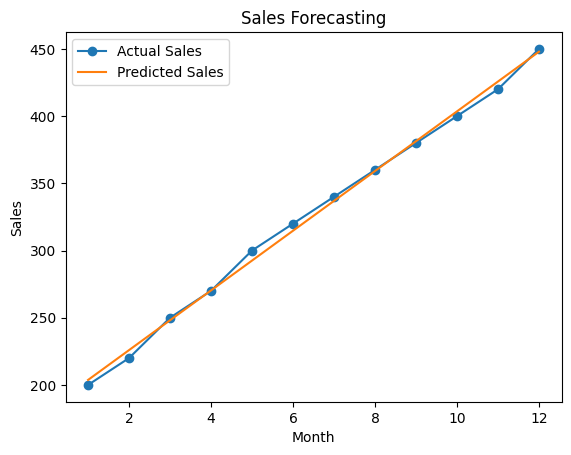

In [16]:
import matplotlib.pyplot as plt

plt.plot(df["month"], df["sales"], marker="o", label="Actual Sales")

plt.plot(df["month"], model.predict(X), label="Predicted Sales")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales Forecasting")

plt.legend()

plt.show()

Business Insight

This model forecasts future sales based on historical monthly sales data.

The prediction trend shows that sales are increasing gradually over time.
Businesses can use this forecast to:

• Plan inventory levels
• Prepare staffing needs
• Estimate future revenue
• Avoid stock shortages or overstock

Although the dataset is simple, the forecasting approach demonstrates how machine learning can support business planning.